# Exercise 02: Summary Statistics (ACF, PACF, Spectrum)

**CBIOMES Workshop · Time Series in R**

Before fitting any model, you want to characterise the temporal structure of your series:

In this notebook, you will:

1. Use **ACF and PACF** as diagnostic fingerprints to classify five different kinds of time series.
2. Apply **spectral analysis** with the periodogram to uncover hidden periodicities.
3. Implement the **autocorrelation function (ACF)** by hand and compare it with R's `acf()`.

## Setup

You are running this notebook inside the workshop **Docker container**, so all required R packages are already installed. You do **not** need to run `install.packages()`.

The data files referenced below should sit next to this notebook:

- `time_series_example_data.csv` — five canonical example series (Random Walk, AR(1), Trend, Seasonal, Structural Break)
- `NPZ_Narragansett_Example.csv` — the NPZ dataset from Exercise 01
- `time_series_balticsea.csv` — the multivariate Baltic Sea dataset

## A short refresher on the concepts

Three tools dominate this notebook. A one-line intuition for each:

| Tool | What it tells you | Typical signature |
|---|---|---|
| **ACF** (Autocorrelation Function) | How correlated `y_t` is with `y_{t-k}` for each lag `k` | AR(1): geometric decay; Random walk: very slow decay; Seasonal: spikes at the season length |
| **PACF** (Partial Autocorrelation) | The correlation at lag `k` *after* removing the effect of shorter lags | AR(p): sharp cutoff after lag `p` |
| **Periodogram** (spectral density) | How variance is distributed across frequencies | Big spike at frequency `f`: cycle of length `1/f` |

**A 30-second R primer reminder** (from Exercise 01):

- Assignment: `x <- 5`
- Column access: `df$col`, with backticks if the name has spaces: `` df$`Z (mg N/m3)` ``
- Sequence 1..n: `1:n` or `seq_len(n)`
- Pipe: `x %>% f() %>% g()`

---

## Exercise 1: ACF and PACF as fingerprints

You are given five canonical time series in `time_series_example_data.csv`:

- **Random Walk** $y_t = \phi y_{t-1} + \varepsilon_t$
- **Stationary AR(1)** short memory around a stable mean
- **Deterministic Trend** straight line + noise
- **Seasonal** periodic component
- **Structural Break** sudden shift

For each one, we will look at three views: the raw series, the ACF, and the PACF.

### Part 1 — Visual inspection

Run the following code and ask yourself:

- Does it fluctuate around a constant mean, or does the mean drift / break / oscillate?
- Are there repeating patterns (seasonality)?
- Are there sudden changes (a break)?

A dashed grey line shows the overall mean. Watch for series that spend long stretches above or below it, it will be imporant later.

**Hints for the loop below:**

- `df_plot[[1]]` grabs the first column (the time index).
- `colnames(df_plot)[-1]` lists every column **except** the first.
- `for (i in seq_along(x))` iterates over the indices of `x`.

In [1]:
# Load and plot the five canonical series
df_plot <- read.csv("time_series_example_data.csv", check.names = FALSE)
head(df_plot)

,Time,Random.Walk,AR.1....stationary,Deterministic.Trend,Seasonal,Structural.Break
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,1.3709584,0.000000000,1.0770046,1.2114152,0.0000000
2,2,0.8062603,-0.004620768,-0.1484829,0.6160854,0.4408241
3,3,1.1693887,0.757007630,0.5723204,0.2551593,-0.6142692
4,4,1.8022513,0.568896254,1.1876533,0.5033147,-0.1476746
5,5,2.2065196,1.133299519,1.0855682,0.3944924,0.2790072
6,6,2.1003951,0.646837037,-0.3605219,1.5345898,0.4633782


Run the following code to plot the canonical time series.

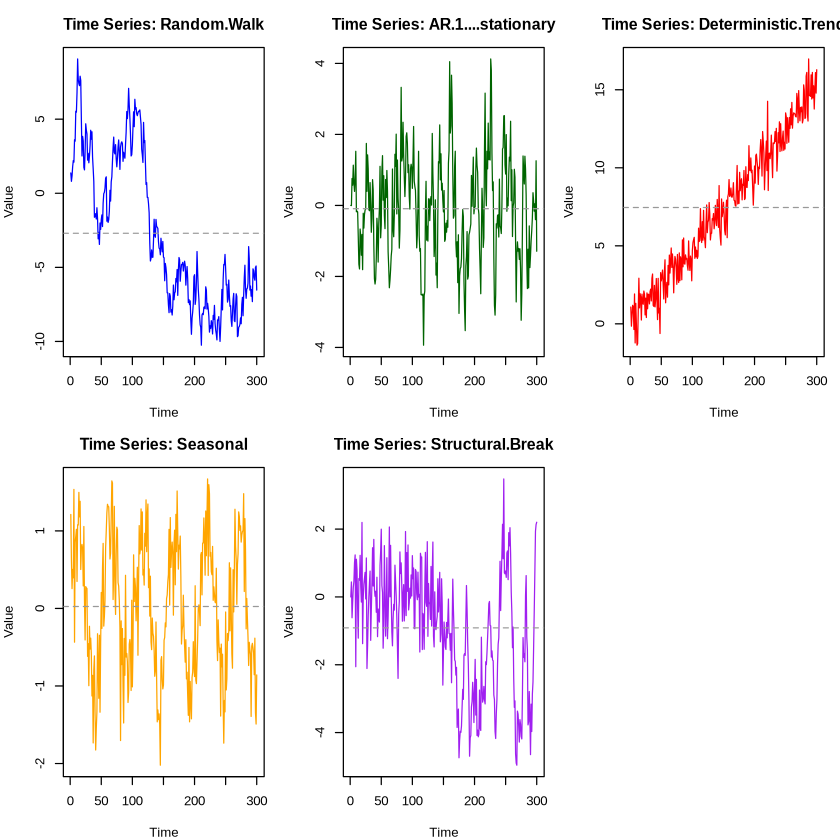

In [2]:
time_vec     <- df_plot[[1]]                  # first column = time
series_names <- colnames(df_plot)[-1]         # all the rest are series
plot_colors  <- c("blue", "darkgreen", "red", "orange", "purple")

# 2 rows x 3 cols panel layout
par(mfrow = c(2, 3), mar = c(4, 4, 3, 1))

for (i in seq_along(series_names)) {
    nm <- series_names[i]
    y_i <- df_plot[[nm]]
    plot(time_vec, y_i,
         type = "l", col = plot_colors[i],
         main = paste("Time Series:", nm),
         xlab = "Time", ylab = "Value")
    abline(h = mean(y_i, na.rm = TRUE), lty = 2, col = "grey60")
}

par(mfrow = c(1, 1))   # reset layout

### Part 2: ACF and PACF for all five series

We'll write a small helper that takes a *list* of series and plots either their ACFs or PACFs in a 2×3 panel. Run the code and interpret the ACF and PACF.

**What to look for:**

| Series | ACF | PACF |
|---|---|---|
| AR(1) | geometric decay | sharp cutoff after lag 1 |
| Random walk | very slow, near-linear decay | strong spike at lag 1, rest small |
| Trend | very slow decay (similar to RW) | strong lag-1 spike |
| Seasonal | recurring spikes at multiples of the period | spikes near the period |
| Structural break | slow decay (mean shift looks like persistence) | lag-1 spike |

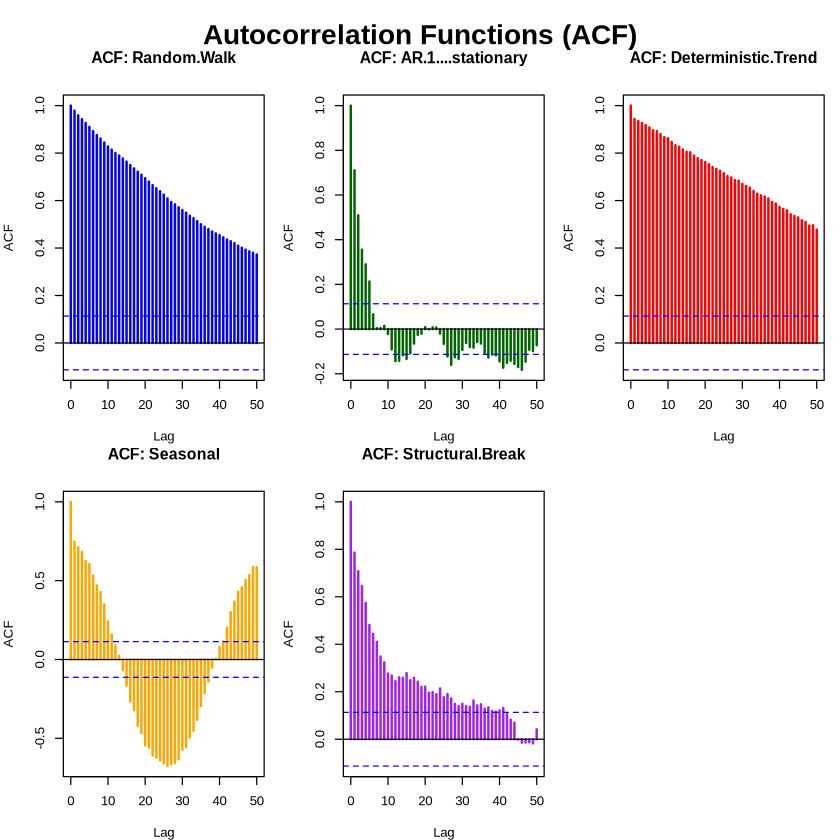

In [3]:
# Build a named list of the five series

series_list <- as.list(df_plot[, -1])         # drop the time column
names(series_list) <- series_names
plot_colors_named  <- setNames(plot_colors, series_names)

# Helper: plot ACF or PACF for each series in the list ---
plot_acf_pacf <- function(series_list, type = c("acf", "pacf"),
                          colors, lag_max = 50) {
    type <- match.arg(type)

    par(mfrow = c(2, 3), mar = c(4, 4, 3, 1), oma = c(0, 0, 3, 0))

    for (i in seq_along(series_list)) {
        nm  <- names(series_list)[i]
        y_i <- series_list[[i]]
        col <- colors[[nm]]

        if (type == "acf") {
            acf(y_i, lag.max = lag_max, col = col, lwd = 2,
                main = paste("ACF:", nm))
        } else {
            pacf(y_i, lag.max = lag_max, col = col, lwd = 2,
                 main = paste("PACF:", nm))
        }
    }

    mtext(ifelse(type == "acf",
                 "Autocorrelation Functions (ACF)",
                 "Partial Autocorrelation Functions (PACF)"),
          outer = TRUE, cex = 1.4, font = 2)

    par(mfrow = c(1, 1))   # reset
}

plot_acf_pacf(series_list, "acf",  plot_colors_named)

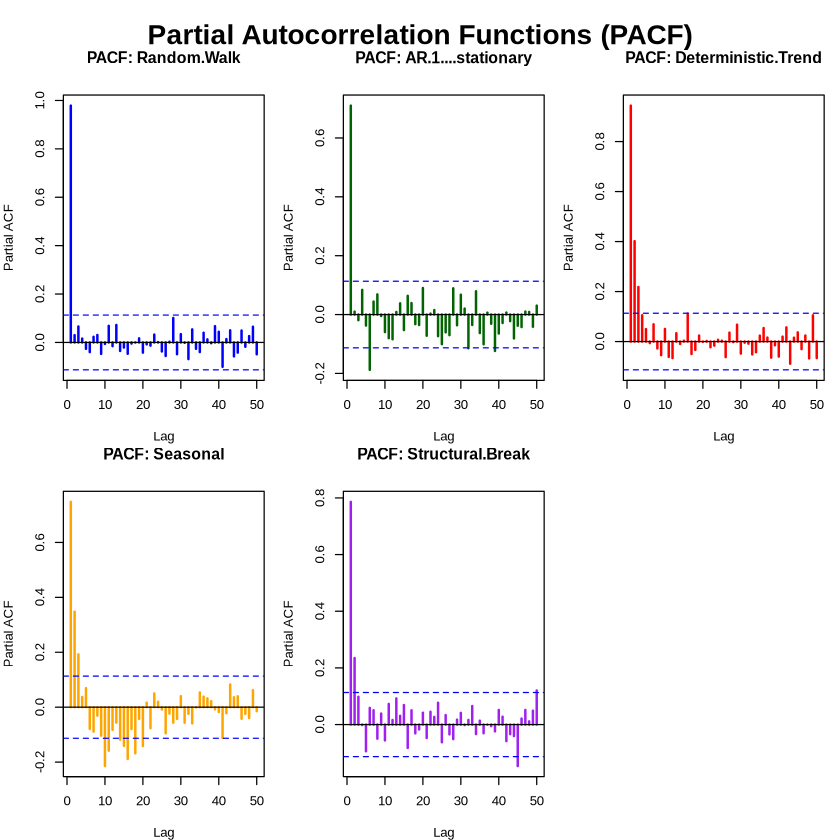

In [4]:
plot_acf_pacf(series_list, "pacf", plot_colors_named)

### How to read these correlograms

These plots are diagnostic fingerprints for the underlying process.

- The AR(1) ACF shows the textbook geometric decay; its PACF cuts off sharply after lag 1.
- The Random Walk and Deterministic Trend ACFs decay very slowly.
- The Seasonal series shows recurring spikes at multiples of its period.
- The Structural Break ACF often *looks* like persistence: a sudden mean shift produces long stretches above or below the mean, which the ACF cannot distinguish from genuine autocorrelation.

### Part 3: Apply to real data

Now run the same diagnostics on real ecological data: the zooplankton series from Exercise 01. Load the data (NPZ_Narragansett_Example.csv) again.

In [5]:
# Real data 1: NPZ zooplankton

npz <- as.data.frame(read.csv("NPZ_Narragansett_Example.csv"))
head(npz)

,time,NO3,P,Z
,<dbl>,<dbl>,<dbl>,<dbl>
1,1,0.2880,0.0379,0.0100
2,8,0.3596,0.0644,0.0006
3,15,0.3569,0.0501,0.0073
4,22,0.4147,0.0343,0.0328
5,29,0.5691,0.0558,0.0016
6,36,0.6366,0.0451,0.0065


Plot the data, run the acf() and pacf() function.

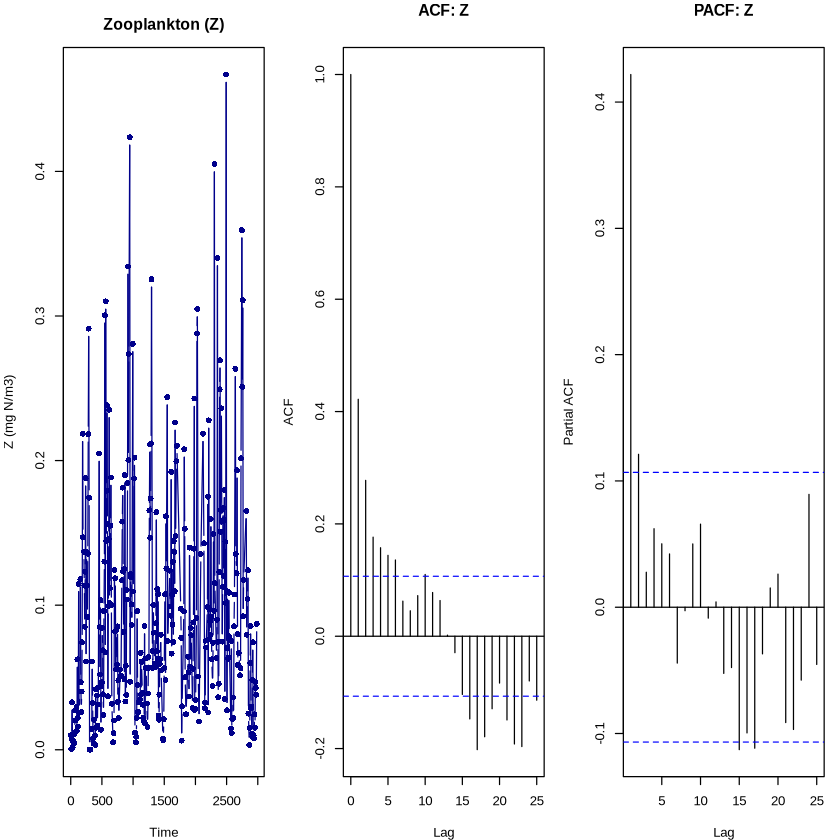

In [6]:
z   <- npz$Z

par(mfrow = c(1, 3), mar = c(4, 4, 3, 1))
plot(npz$time, z, type = "b", pch = 16, col = "darkblue",
     main = "Zooplankton (Z)", xlab = "Time", ylab = "Z (mg N/m3)")
acf(z,  main = "ACF: Z")
pacf(z, main = "PACF: Z")
par(mfrow = c(1, 1))

**Reading the Z series.** The plot fluctuates around a stable mean, the ACF decays fairly quickly, and the PACF has a dominant spike at lag 1 with a sharp cutoff, classic AR signature. The mild negative ACF dip near lag 15 hints at a weak secondary cycle that a higher-order or seasonal model could capture.

**Bonus:** Run the same for the baltic sea dataset.

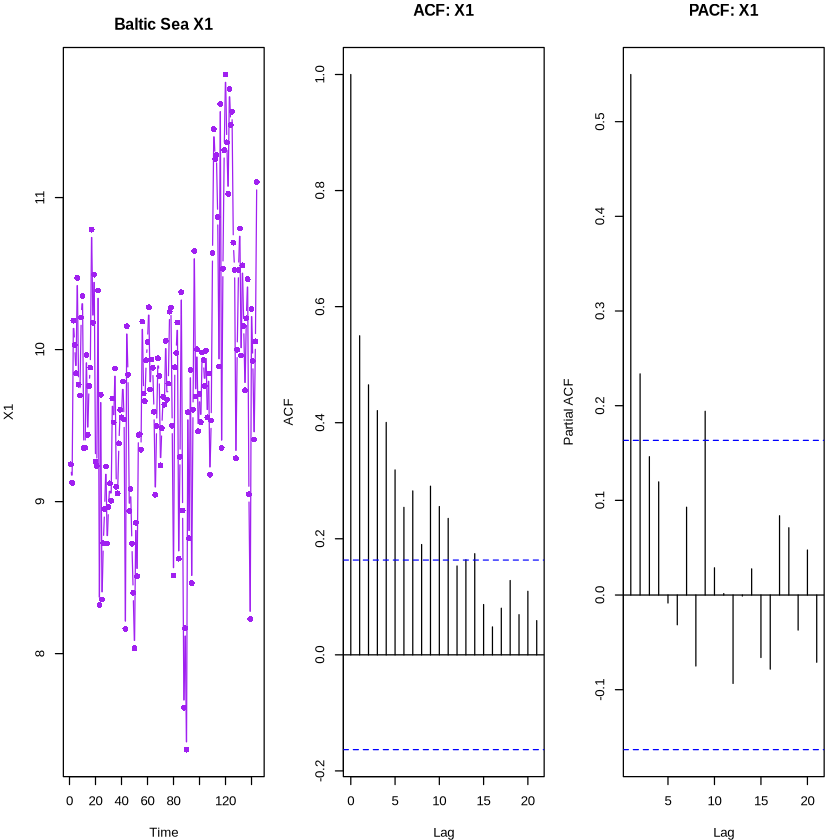

In [7]:
# Real data 2: Baltic Sea, variable X1

time_series_imp <- as.data.frame(read.csv("time_series_balticsea.csv"))
x1 <- time_series_imp[[1]]                    # use the first column

par(mfrow = c(1, 3), mar = c(4, 4, 3, 1))
plot(seq_along(x1), x1, type = "b", pch = 16, col = "purple",
     main = "Baltic Sea X1", xlab = "Time", ylab = "X1")
acf(x1,  main = "ACF: X1")
pacf(x1, main = "PACF: X1")
par(mfrow = c(1, 1))

**Reading X1.** The series fluctuates around ~9.5 with visible clusters of high and low values. The ACF shows a smooth geometric decay → stationary autoregressive structure. The PACF cuts off after **two** significant spikes → an AR(2) is a reasonable first guess.

---

## Exercise 2: Spectral density (the periodogram)

Where the ACF lives in the time domain, the periodogram lives in the frequency domain. It tells you how the variance of the series is distributed across frequencies.

**Key relationship:** if you see a spectral peak at frequency $f$, the series has a cycle of period

$$ T \;=\; \frac{1}{f}. $$

So a peak at $f = 0.02$ means a cycle of length 50.

**The R function:** `spec.pgram(x, spans = c(5, 5), log = "no")`.

- `spans` controls **smoothing**. Without it, the periodogram is extremely noisy. `c(5, 5)` applies two passes of a length-5 smoother.
- `log = "no"` plots the spectrum on a linear scale (the default is log).

### Tasks

1. Extract the `Seasonal` series from the example dataset `df_plot`.
2. Compute and plot its smoothed periodogram using spec.pgram with spans = c(5, 5) and log = "no".
3. Identify the dominant frequency.
4. Convert that frequency to a period and compare with the visual cycle length in the time plot.

### Hints

- The example CSV has a column called `Seasonal` — pull it out with `df_plot$Seasonal` or `df_plot[["Seasonal"]]`.
- The peak frequency is the `freq` value where the `spec` is maximal: `out <- spec.pgram(...); out$freq[which.max(out$spec)]`.

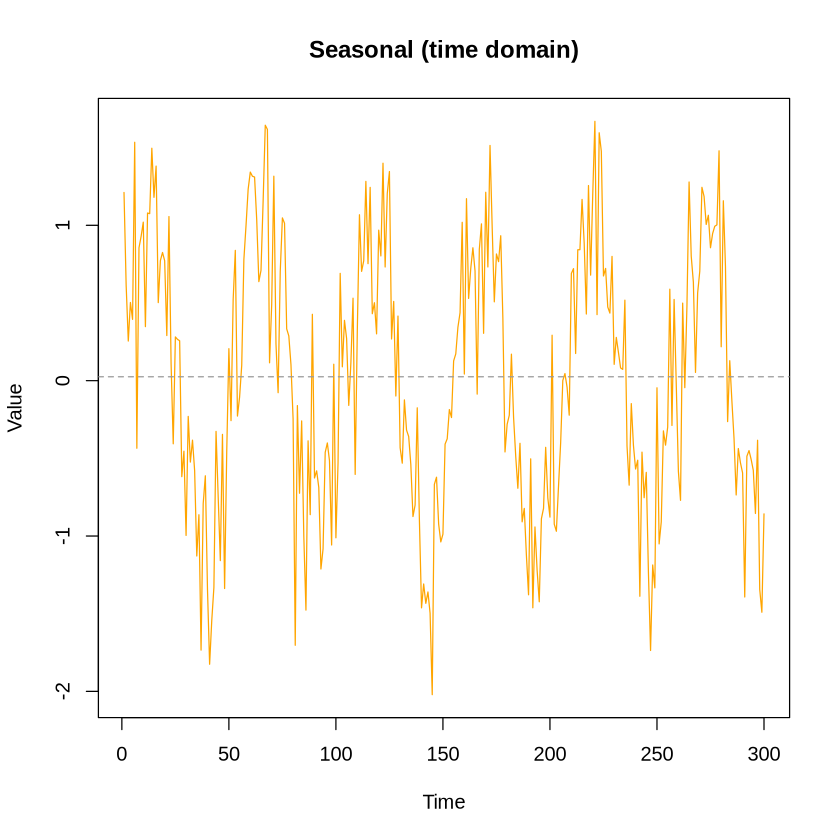

In [8]:
# --- Smoothed periodogram of the Seasonal series ---
y_seasonal <- df_plot[["Seasonal"]]

plot(time_vec, y_seasonal, type = "l", col = "orange",
     main = "Seasonal (time domain)",
     xlab = "Time", ylab = "Value")
abline(h = mean(y_seasonal), lty = 2, col = "grey60")

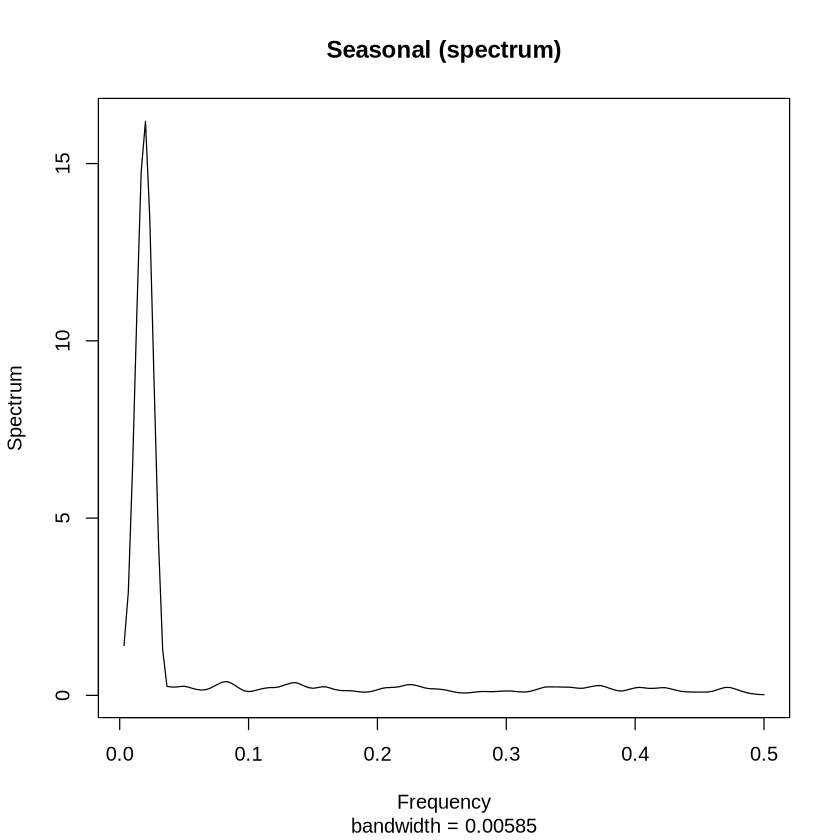

In [9]:
# 2.
spec_out <- spec.pgram(y_seasonal,
                       spans = c(5, 5), log = "no",
                       main  = "Seasonal (spectrum)",
                       col   = "black",
                       xlab  = "Frequency", ylab = "Spectrum")

In [10]:
# 3. and 4. Find the dominant frequency / period 
peak_freq   <- spec_out$freq[which.max(spec_out$spec)]
peak_period <- 1 / peak_freq
cat(sprintf("Dominant frequency: %.4f\n", peak_freq))
cat(sprintf("Implied period:     %.1f time steps per cycle\n", peak_period))

Dominant frequency: 0.0200
Implied period:     50.0 time steps per cycle


**What this means.** The series oscillates around zero with a clear repeating pattern, and the periodogram pins that pattern to a single dominant low-frequency peak. Inverting the frequency gives the cycle length.

The smoothing (`spans = c(5, 5)`) is what makes the peak clearly visible: an unsmoothed periodogram is wildly noisy and hard to interpret.

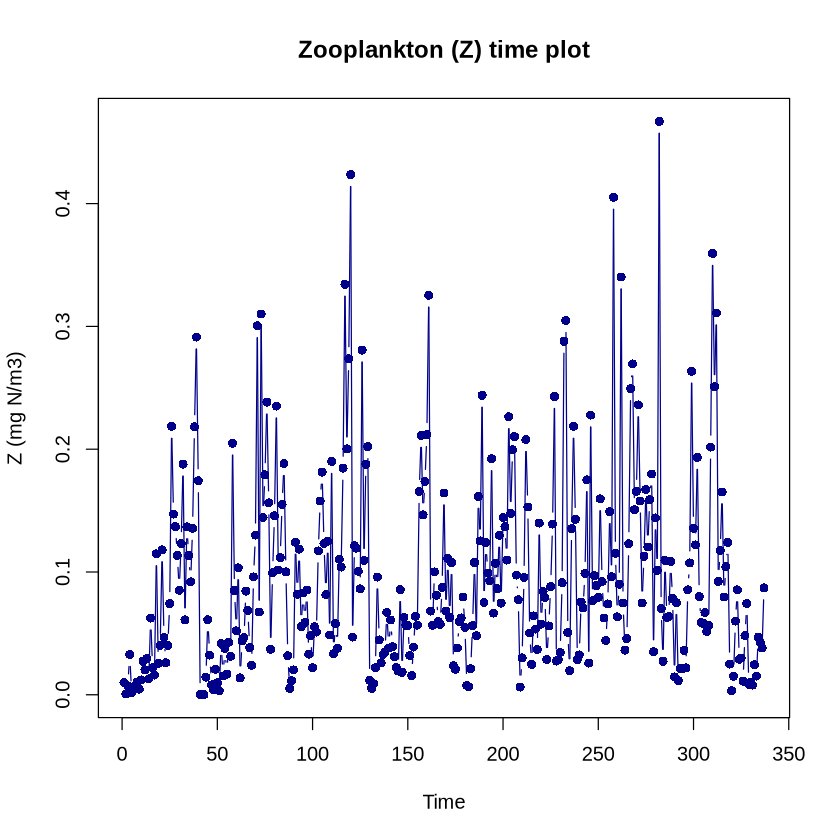

Z: dominant frequency = 0.0250, implied period = 40.0 time steps


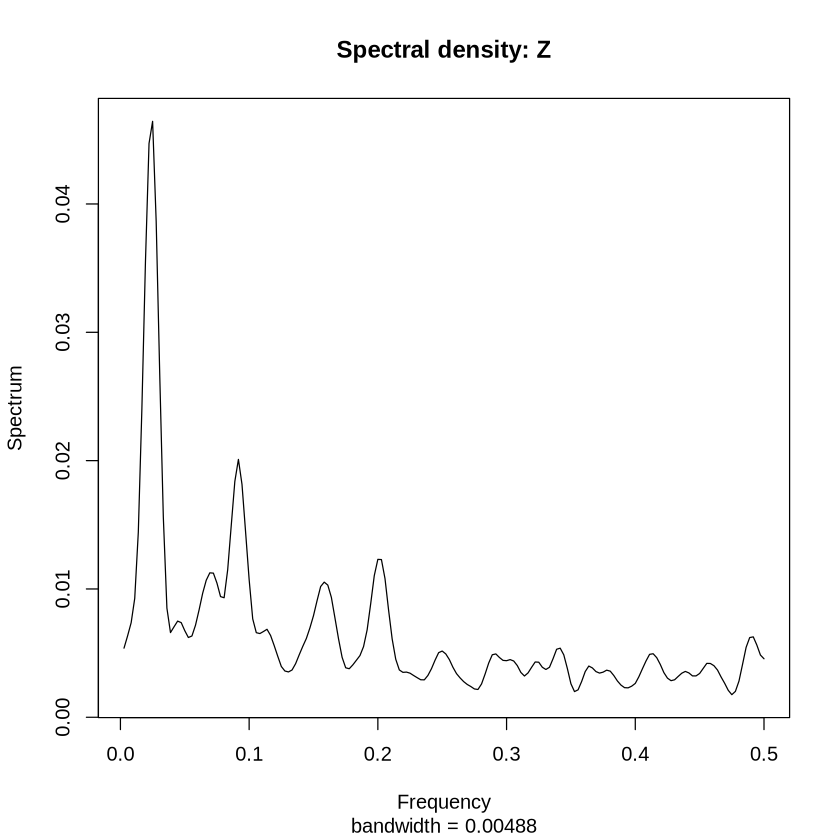

In [11]:
# Apply to NPZ zooplankton

plot(seq_along(z), z, type = "b", pch = 16, col = "darkblue",
     main = "Zooplankton (Z) time plot",
     xlab = "Time", ylab = "Z (mg N/m3)")
spec_z <- spec.pgram(z, spans = c(5, 5), log = "no",
                     main = "Spectral density: Z",
                     col = "black", xlab = "Frequency", ylab = "Spectrum")

peak_freq_z   <- spec_z$freq[which.max(spec_z$spec)]
peak_period_z <- 1 / peak_freq_z
cat(sprintf("Z: dominant frequency = %.4f, implied period = %.1f time steps\n",
            peak_freq_z, peak_period_z))

**Reading Z's spectrum.** The variance is concentrated at low frequencies, a primary peak near $f \approx 0.025$ implies a dominant cycle of roughly 40 time steps, plausibly the seasonal pulse of the ecosystem. Smaller secondary peaks at higher frequencies hint at harmonic or shorter-term cycles.

**Bonus:** Run the same for the baltic sea dataset.

X1: dominant frequency = 0.0069, implied period = 144.0 time steps


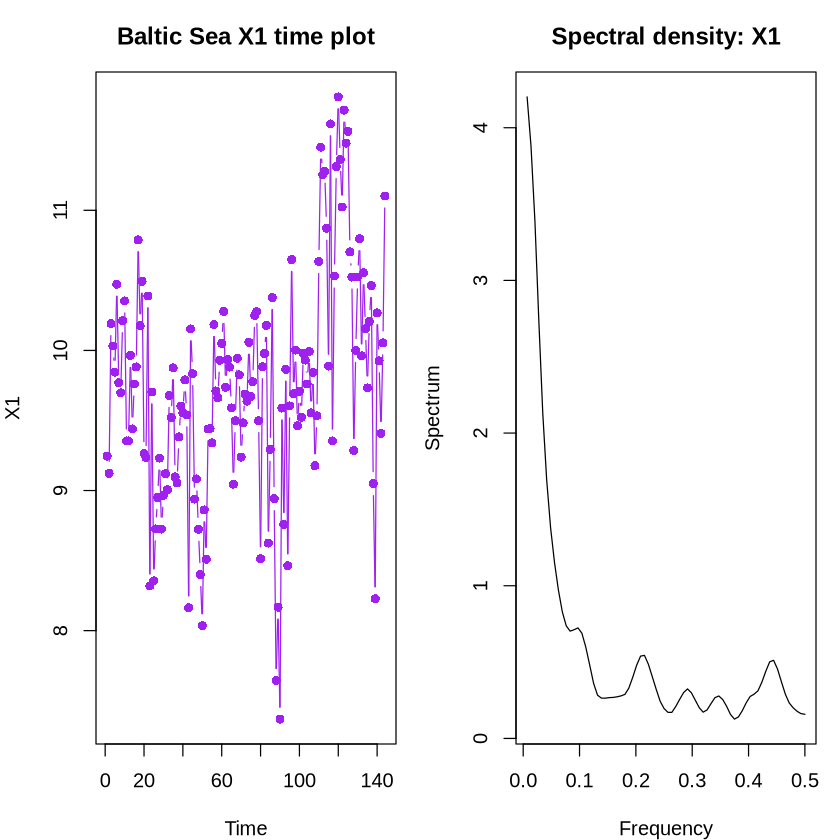

In [12]:
# Apply to Baltic Sea X1

par(mfrow = c(1, 2), mar = c(4, 4, 3, 1))
plot(seq_along(x1), x1, type = "b", pch = 16, col = "purple",
     main = "Baltic Sea X1 time plot",
     xlab = "Time", ylab = "X1")
spec_x1 <- spec.pgram(x1, spans = c(5, 5), log = "no",
                      main = "Spectral density: X1",
                      col = "black", xlab = "Frequency", ylab = "Spectrum")
par(mfrow = c(1, 1))

peak_freq_x1   <- spec_x1$freq[which.max(spec_x1$spec)]
peak_period_x1 <- 1 / peak_freq_x1
cat(sprintf("X1: dominant frequency = %.4f, implied period = %.1f time steps\n",
            peak_freq_x1, peak_period_x1))

**Reading X1's spectrum.** Power piles up near $f = 0$, a classic **"red noise"** signature. This says the variance is dominated by long, slow excursions rather than fast oscillations. That matches the time plot, where the series stays above or below its mean for extended stretches (especially the hump around index 110–130). Red-noise behaviour is what you'd expect from a strongly autoregressive process, consistent with the AR(2)-like PACF cutoff we found in Exercise 2.

### Discussion

- Why does smoothing (`spans`) matter? What changes if you set `spans = c(3)` or omit it entirely?
- A peak at $f = 0$ is special — what does it usually indicate? (Trend / non-stationarity / red noise.)
- How would the spectrum of a **pure white noise** series look? (Flat, equal power at all frequencies.)
- ACF vs PACF vs periodogram: when would you prefer each?

### Common pitfalls

- The `freq` axis from `spec.pgram` is in **cycles per time step**. If your time steps are months and the peak is at 1/12, the cycle is annual, but only because the time step is monthly.
- Forgetting `log = "no"` shows the spectrum on a log scale, which compresses peaks and is harder to read for beginners.

---

## (Optional) Exercise 3: Computing the ACF from scratch

**Goal:** Implement the sample ACF using its mathematical definition and check that it matches R's built-in `acf()`.

The sample autocorrelation at lag $k$ is:

$$
\hat{\rho}(k) \;=\; \frac{\sum_{t=k+1}^{T}(y_t - \bar{y})(y_{t-k} - \bar{y})}{\sum_{t=1}^{T}(y_t - \bar{y})^2}
$$

### Part 1: Understanding the data

We will simulate data first. Just run the cell. We will use a so called **AR(1) process** with $\phi = 0.6$:

$$ y_t = \phi\, y_{t-1} + \varepsilon_t, \quad \varepsilon_t \sim \mathcal{N}(0,1) $$

We will discuss this again later.

In [13]:
# Simulate the AR(1) process
set.seed(123)        # reproducible random numbers
phi <- 0.6
n   <- 500

y   <- numeric(n)        # pre-allocate length-n vector of zeros
eps <- rnorm(n)          # white-noise innovations

for (t in 2:n) {
    y[t] <- phi * y[t - 1] + eps[t]
}

Plot the data.

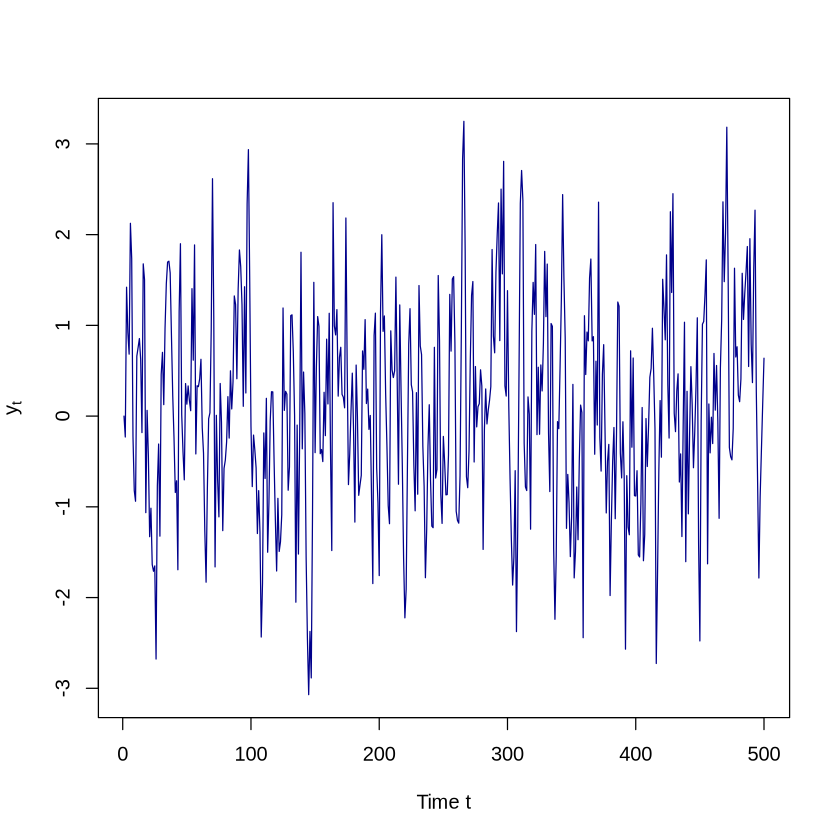

In [14]:
# Quick look at the simulated series
plot(y, type = "l", col = "darkblue",
     xlab = "Time t", ylab = expression(y[t]))

### (Optional) Part 2: Manual ACF implementation

**Tasks:**

1. Centre the series: $\tilde{y}_t = y_t - \bar{y}$.
2. For each lag $k = 0, 1, \dots, 20$, compute the numerator $\sum_{t=k+1}^{T} \tilde{y}_t \tilde{y}_{t-k}$.
3. Divide by the denominator $\sum_t \tilde{y}_t^2$.

**Hints:**

- `mean(x)`, `sum(x^2)` are vectorised, no loops needed for the denominator.
- For the numerator at lag `k`, you need `x[(k+1):n]` paired with `x[1:(n-k)]`.
- Pre-allocate the result with `numeric(max_lag + 1)` and fill it in a loop.

<details>
<summary><b>Hint 1</b></summary>

Centre the series first, then the formula simplifies:

```r
x <- y - mean(y)
denom <- sum(x^2)
```
</details>

<details>
<summary><b>Hint 2</b></summary>

The two slices for lag `k`:

```r
left  <- x[(k + 1):n]   # y_t
right <- x[1:(n - k)]   # y_{t-k}
num   <- sum(left * right)
```
</details>

<details>
<summary><b>Full solution</b></summary>

```r
my_acf <- function(x, max_lag) {
    n <- length(x)
    x <- x - mean(x)
    denom <- sum(x^2)
    out <- numeric(max_lag + 1)
    for (k in 0:max_lag) {
        out[k + 1] <- sum(x[(k + 1):n] * x[1:(n - k)]) / denom
    }
    out
}
```
</details>

In [15]:
# Manual ACF function

my_acf <- function(x, max_lag) {
    n <- length(x)
    x <- x - mean(x)            # centre the series
    denom <- sum(x^2)           # total variance (denominator)

    acf_vals <- numeric(max_lag + 1)   # pre-allocate
    for (k in 0:max_lag) {
        # Pair y_t with y_{t-k}, multiply, sum
        num <- sum(x[(k + 1):n] * x[1:(n - k)])
        acf_vals[k + 1] <- num / denom
    }
    acf_vals
}

max_lag    <- 20
acf_manual <- my_acf(y, max_lag)
round(acf_manual, 3)

[1]  1.000  0.525  0.258  0.125  0.022 -0.007 -0.023  0.012  0.039  0.035
[11]  0.006 -0.032 -0.086 -0.032  0.019  0.038 -0.029 -0.040 -0.061 -0.031
[21] -0.021

### Part 3: Comparison with R's `acf()`

`acf()` returns a list; the numbers we want are in `$acf`. Pass `plot = FALSE` to suppress the default plot.

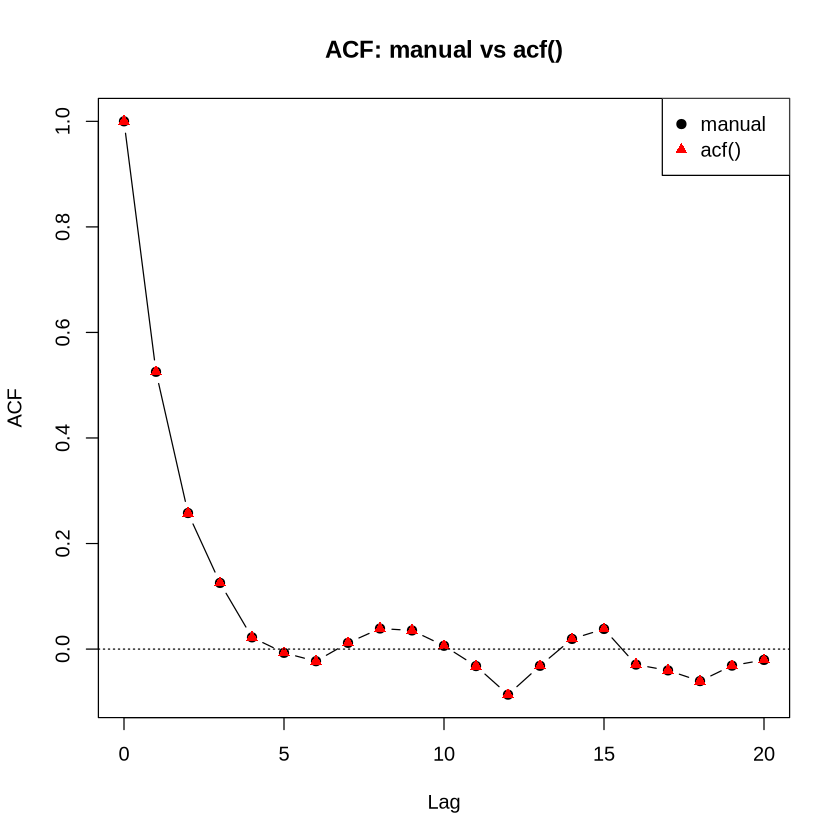

In [16]:
# Built-in ACF and side-by-side plot

acf_builtin <- acf(y, lag.max = max_lag, plot = FALSE)$acf
lags <- 0:max_lag

plot(lags, acf_manual,
     type = "b", pch = 19,
     main = "ACF: manual vs acf()",
     xlab = "Lag", ylab = "ACF")
points(lags, acf_builtin, col = "red", pch = 17)
abline(h = 0, lty = 3)
legend("topright",
       legend = c("manual", "acf()"),
       pch    = c(19, 17),
       col    = c("black", "red"))

### Part 4: Interpretation

- **Decay rate.** The ACF should drop roughly geometrically: $\rho(k) \approx \phi^{|k|}$. With $\phi = 0.6$ that means $\rho(1) \approx 0.6$, $\rho(2) \approx 0.36$, $\rho(3) \approx 0.22$, etc. Check the printed values against your expectation.
- **Why this matters.** The shape of the ACF is the main clue for choosing the order of an ARMA model. A slow, near-linear decay would tell us the series is non-stationary and needs differencing instead.

### Discussion

- How would the ACF look for:
  - a **random walk**? (very slow, near-linear decay)
  - a **seasonal series** with period 12? (recurring spikes at lags 12, 24, 36, …)

---

## Wrap-up

You should now be able to:

- Compute an ACF from its definition and verify against `acf()`.
- Read **ACF and PACF** correlograms and recognise classic fingerprints (AR, MA, random walk, trend, seasonal, structural break).
- Compute and interpret a smoothed **periodogram**, converting peaks to cycle lengths.
- Apply all three tools to real ecological data.

---

## Where this fits in the workflow

```
Plot raw data (Exercise 01)
       ↓
[Summary stats: ACF, PACF, spectrum]   ← you are here
       ↓
Stationarity tests (Exercise 05) — needed before fitting AR/VAR
       ↓
Single-variable models (Exercises 03, 04)
       ↓
Multivariate models (Exercises 06, 08, 09, 10)
```